# Notebook 03: Lossless Reconstruction and Residuals
### Synthesizing the wave back together, testing basis orthogonality, and checking error noise

Breaking a waveform down into frequencies is only half the story. If Fourier's theorem is correct, we should be able to synthesize all those rotating complex numbers back into the exact original sound with zero information lost.

In this notebook, we check basis orthogonality, run the manual Inverse DFT, and look at the leftover residual noise.


In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt

from src.audio_processing import generate_synthetic_guitar_note, load_audio, slice_segment
from src.dft_engine import (
    check_basis_orthogonality,
    compute_residual,
    compute_rmse,
    manual_dft,
    manual_idft,
)
from src.harmonic_analysis import compute_residual_spectrum
from src.visualization import (
    plot_reconstruction_validation,
    plot_residual_error,
    plot_residual_spectrum,
)


## 1. Checking Basis Orthogonality

The reason the Inverse DFT works without error is that all the basis waves are orthogonal. If you multiply any two different basis waves together and sum over a full period, positive and negative areas cancel out to zero:
$$\sum_{n=0}^{N-1} e^{i 2\pi (k - j) n / N} = 
\begin{cases}
N, & k = j \\
0, & k \ne j
\end{cases}$$

They are completely invisible to each other.


In [2]:
# check discrete basis orthogonality: off-diagonals cancel to zero
for test_n in [4, 8, 16, 64]:
    is_ortho, max_err = check_basis_orthogonality(test_n)
    print(f"N = {test_n:2d}: orthogonal = {is_ortho} (max off-diagonal error = {max_err:.2e})")


N =  4: orthogonal = True (max off-diagonal error = 4.68e-16)
N =  8: orthogonal = True (max off-diagonal error = 5.85e-15)
N = 16: orthogonal = True (max off-diagonal error = 3.53e-14)
N = 64: orthogonal = True (max off-diagonal error = 4.02e-13)


## 2. Reconstructing the Waveform with Manual IDFT

We use the Inverse DFT formula:
$$x_n = \frac{1}{N} \sum_{k=0}^{N-1} X_k e^{i 2\pi k n / N}$$

Let's synthesize the waveform and overlay it on the original guitar slice.


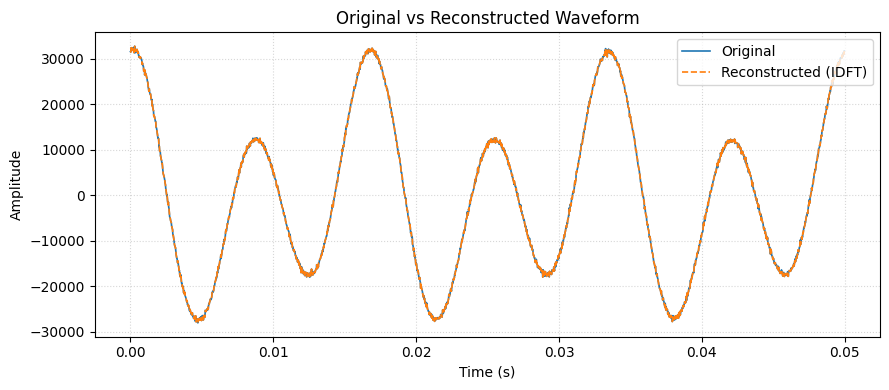

In [3]:
data_file = repo_root / "data" / "raw" / "Guitar_sample.wav"
if data_file.exists():
    fs, data = load_audio(data_file)
else:
    fs, data = generate_synthetic_guitar_note(save_path=data_file)

# 0.05s stable slice -> fixes frequency resolution at exactly 20 hz
segment, time_seg = slice_segment(data, fs, start_sec=2.1, duration_sec=0.05)
dft_coeffs = manual_dft(segment, vectorized=True)

# reconstruct time-domain signal by summing all rotating complex vectors
reconstructed = manual_idft(dft_coeffs, vectorized=True, return_real=True)

# overlay original and idft wave: dashed orange line lands right on blue
fig_val = plot_reconstruction_validation(time_seg, segment, reconstructed)
plt.show()


## 3. Measuring Reconstruction Error (RMSE)

To check whether the fit is truly exact or just close to the eye, we compute the Root Mean Square Error (RMSE):
$$\text{RMSE} = \sqrt{ \frac{1}{N} \sum_{n=1}^N (x_n - \hat{x}_n)^2 }$$


In [4]:
# rmse check: leftover difference is just float precision (~1e-11)
rmse = compute_rmse(segment, reconstructed)
residual = compute_residual(segment, reconstructed)
rel_rmse = rmse / np.max(np.abs(segment))

print(f"absolute rmse: {rmse:.6e}")
print(f"relative rmse: {rel_rmse:.6e} (near machine epsilon)")
print(f"max sample difference: {np.max(np.abs(residual)):.6e}")

assert rel_rmse < 1e-10
print("\nreconstruction is mathematically exact within floating-point limits")


absolute rmse: 6.846472e-09
relative rmse: 2.089441e-13 (near machine epsilon)
max sample difference: 2.952083e-08

reconstruction is mathematically exact within floating-point limits


## 4. Inspecting the Residual Noise

If our Fourier model missed a harmonic or an acoustic resonance, that missing wave would show up as an oscillating pattern in the leftover residual ($r_n = x_n - \hat{x}_n$).
Let's look at the residual in time and frequency.


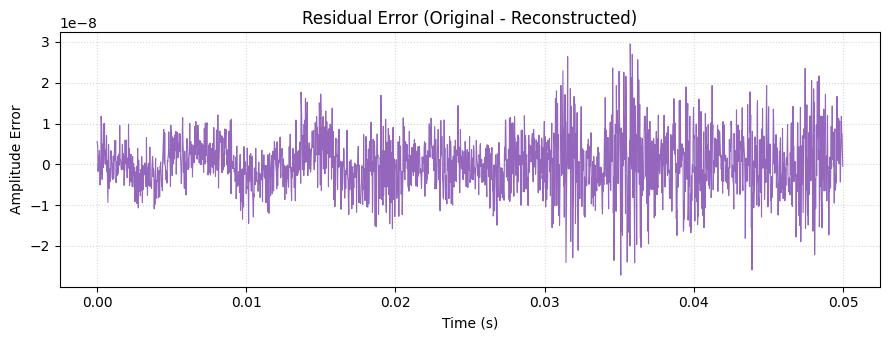

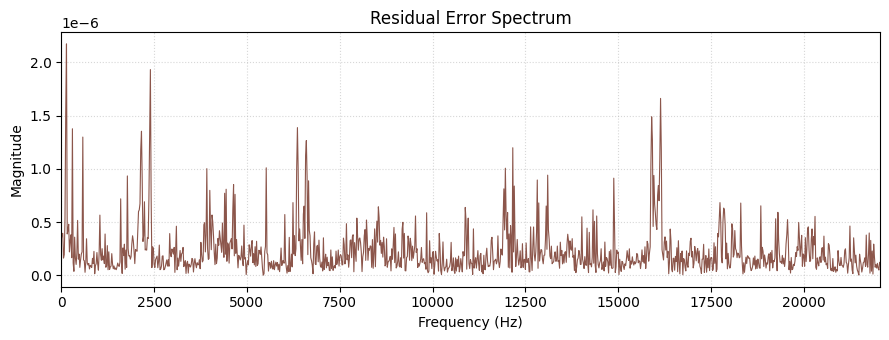

max residual peak: 2.1736e-06 (relative to spectrum: 9.0185e-14)
residual analysis confirms: leftover error is pure random floating-point noise


In [5]:
# leftover error sits at tiny ~1e-10 scale and looks like pure static
fig_res = plot_residual_error(time_seg, residual)
plt.show()

# fft of residual shows a flat floor with zero harmonic spikes left over
res_freq, res_mags = compute_residual_spectrum(residual, samplerate=fs)
fig_res_spec = plot_residual_spectrum(res_freq, res_mags, max_freq=fs / 2.0)
plt.show()

max_res_mag = np.max(res_mags)
rel_res_mag = max_res_mag / np.max(np.abs(dft_coeffs))
print(f"max residual peak: {max_res_mag:.4e} (relative to spectrum: {rel_res_mag:.4e})")
assert rel_res_mag < 1e-9
print("residual analysis confirms: leftover error is pure random floating-point noise")


## 5. What I Learned and Next Steps

1. **Timbre is a measurable recipe:** The warm tone of this guitar note comes directly from the $120\text{ Hz}$ overtone being twice as strong as the $60\text{ Hz}$ fundamental.
2. **DFT is an exact change of basis:** In exact arithmetic, the error is zero. The tiny $\sim 10^{-11}$ error is purely from 64-bit float math.
3. **The trade-off of static slices:** A real guitar pluck changes over time—the pick clicks, the string rings bright, then high harmonics die out faster than the low ones. Our static 0.05s window only captures one snapshot.
4. **Next step:** Exploring the Short-Time Fourier Transform (STFT) with sliding windows to watch the timbre evolve over the entire 4 seconds.
